In [1]:
import pandas as pd   
import numpy as np   
import matplotlib.pyplot as plt   
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing 
from sklearn.pipeline import Pipeline 
import statsmodels.api as sm
from statsmodels.api import OLS
import warnings 
warnings.filterwarnings('ignore') 

In [2]:
!pip install statsmodels

In [3]:
data = fetch_california_housing() 
X,y = data.data , data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [5]:
preprocessing_pipeline = Pipeline([
    ('standard_scaler', StandardScaler()),
    ("minmax_scaler", MinMaxScaler())
    ])

In [6]:
x_train_scaled = preprocessing_pipeline.fit_transform(X_train)  
X_test_scaled = preprocessing_pipeline.fit_transform(X_test) 

In [7]:
#adding constats to training and test data sets 

In [8]:
X_train_scaled_sm = sm.add_constant(x_train_scaled) 
X_test_scaled_sm = sm.add_constant(X_test_scaled)

In [10]:
model = OLS(y_train, X_train_scaled_sm).fit()

In [11]:
model.params
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     2699.
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:42:40   Log-Likelihood:                -15979.
No. Observations:               14448   AIC:                         3.198e+04
Df Residuals:                   14439   BIC:                         3.204e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7891      0.081     47.040      0.000       3.631       3.947
x1             6.2285      0.072     86.021      0.000       6.087       6.370
x2             0.4883      0.027     17.876      0.000       0.435       0.542
x3           -14.1415      0.975    -14.499      0.000     -16.053     -12.230
x4            20.4412      1.118     18.280      0.000      18.249      22.633
x5            -0.1460      0.200     -0.729      0.466      -0.539       0.247
x6            -4.8592      0.659     -7.372      0.000      -6.151      -3.567
x7            -3.9753      0.082    -48.756      0.000      -4.135      -3.815
x8            -4.3862      0.091    -48.027      0.000      -4.565      -4.207
==============================================================================
Omnibus:                     3086.265   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10570.013
Skew:                           1.063   Prob(JB):                         0.00
Kurtosis:                       6.611   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
print(x_train_scaled.shape)
print(y_train.shape)

(14448, 8)
(14448,)


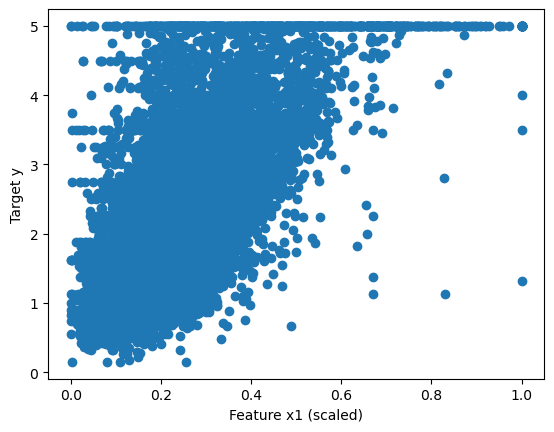

In [16]:
plt.scatter(x_train_scaled[:, 0], y_train)
plt.xlabel("Feature x1 (scaled)")
plt.ylabel("Target y")
plt.show()
